# 🔍 TrustLens: Hybrid Spatial-Temporal Deepfake Detection
## Training & Multi-Dataset Evaluation Notebook

**Architecture**: ResNeXt-50 (spatial) + BiLSTM (temporal) + SigLIP (classifier) → Weighted Fusion

**Datasets**:
- Celeb-DF v2 (kaggle: reubensuju/celeb-df-v2)
- FaceForensics++ (kaggle: hungnm/faceforensics-processed-images)
- OpenForensics (kaggle: sauravmaheshkar/openforensics)

**Pipeline**:
1. Install dependencies
2. Authenticate Kaggle + download datasets
3. Build dataset loaders
4. Define TrustLens model (3-branch)
5. Train on each dataset
6. Evaluate + report per-dataset metrics
7. Cross-dataset generalization test
8. Save models + results

## Cell 1 — Install Dependencies

In [ ]:
%%capture
!pip install kagglehub timm transformers accelerate scikit-learn matplotlib seaborn tqdm opencv-python-headless Pillow
print('✅ Dependencies installed')

## Cell 2 — GPU Check + Imports

In [ ]:
import os, sys, json, time, random, shutil, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report,
    average_precision_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from torchvision.models import ResNeXt50_32X4D_Weights

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print('✅ Imports done')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB
✅ Imports done


## Cell 3 — Kaggle Authentication

> **Required**: Upload your `kaggle.json` (from kaggle.com → Account → API → Create New Token) using the files panel on the left, OR paste your credentials in the cell below.

In [ ]:
import kagglehub

# ── Option A: if you uploaded kaggle.json to the session ──────────────────────
kaggle_json_path = '/content/kaggle.json'
if os.path.exists(kaggle_json_path):
    os.makedirs(os.path.expanduser('~/.config/kaggle'), exist_ok=True)
    shutil.copy(kaggle_json_path, os.path.expanduser('~/.config/kaggle/kaggle.json'))
    os.chmod(os.path.expanduser('~/.config/kaggle/kaggle.json'), 0o600)
    print('✅ kaggle.json found and configured')

# ── Option B: paste credentials directly (fill in your values) ───────────────
else:
    KAGGLE_USERNAME = "trustlens"   # ← your kaggle username
    KAGGLE_KEY      = "KGAT_5745fd2099d05be0d23bcfd437d1073a"   # ← your kaggle API key
    if KAGGLE_USERNAME and KAGGLE_KEY:
        os.makedirs(os.path.expanduser('~/.config/kaggle'), exist_ok=True)
        creds = {'username': KAGGLE_USERNAME, 'key': KAGGLE_KEY}
        with open(os.path.expanduser('~/.config/kaggle/kaggle.json'), 'w') as f:
            json.dump(creds, f)
        os.chmod(os.path.expanduser('~/.config/kaggle/kaggle.json'), 0o600)
        os.environ['KAGGLE_USERNAME'] = KAGGLE_USERNAME
        os.environ['KAGGLE_KEY'] = KAGGLE_KEY
        print('✅ Kaggle credentials set from inline values')
    else:
        print('⚠️  No Kaggle credentials found. Fill KAGGLE_USERNAME / KAGGLE_KEY above.')

✅ Kaggle credentials set from inline values


## Cell 4 — Download Datasets via kagglehub

In [ ]:
print('Downloading Celeb-DF v2...')
try:
    celebdf_path = kagglehub.dataset_download('reubensuju/celeb-df-v2')
    DATASET_PATHS['celebdf'] = celebdf_path
    print(f'  ✅ Celeb-DF v2 → {celebdf_path}')
except Exception as e:
    print(f'  ❌ Celeb-DF v2 failed: {e}')

print(f'\n📦 Downloaded datasets: {list(DATASET_PATHS.keys())}')

Using Colab cache for faster access to the 'celeb-df-v2' dataset.
  ✅ Celeb-DF v2 → /kaggle/input/celeb-df-v2

📦 Downloaded datasets: ['celebdf', 'dffmd']


## Cell 5 — Dataset Path Inspector
Walks downloaded directories to understand their structure and locate real/fake image folders.

In [ ]:
def walk_tree(root, max_depth=3, max_per_level=8):
    """Print directory tree up to max_depth."""
    root = Path(root)
    print(f'\n📂 {root}')
    for dirpath, dirs, files in os.walk(root):
        depth = len(Path(dirpath).relative_to(root).parts)
        if depth > max_depth:
            continue
        indent = '  ' * depth
        dirs[:] = sorted(dirs)[:max_per_level]
        print(f'{indent}📁 {Path(dirpath).name}/  ({len(files)} files)')
        for f in sorted(files)[:3]:
            print(f'{indent}  📄 {f}')

for name, path in DATASET_PATHS.items():
    print(f'\n{'='*60}')
    print(f'Dataset: {name}')
    walk_tree(path, max_depth=3)

print('\n✅ Inspection done — use the structure above to confirm path mappings in Cell 6')


Dataset: celebdf

📂 /kaggle/input/celeb-df-v2
📁 celeb-df-v2/  (1 files)
  📄 List_of_testing_videos.txt
  📁 Celeb-real/  (590 files)
    📄 id0_0000.mp4
    📄 id0_0001.mp4
    📄 id0_0002.mp4
  📁 Celeb-synthesis/  (5639 files)
    📄 id0_id16_0000.mp4
    📄 id0_id16_0001.mp4
    📄 id0_id16_0002.mp4
  📁 YouTube-real/  (300 files)
    📄 00000.mp4
    📄 00001.mp4
    📄 00002.mp4

Dataset: dffmd

📂 /root/.cache/kagglehub/datasets/hhalalwi/deepfake-face-mask-dataset-dffmd/versions/1
📁 1/  (1 files)
  📄 DFFD_metadata.json
  📁 Fake/  (0 files)
    📁 Fake/  (1000 files)
      📄 vid1000_f.mp4
      📄 vid100_f.mp4
      📄 vid101_f.mp4
  📁 Real/  (0 files)
    📁 Real/  (836 files)
      📄 vid1000_.mp4
      📄 vid100_.mp4
      📄 vid101_.mp4

✅ Inspection done — use the structure above to confirm path mappings in Cell 6


In [ ]:
# Run this BEFORE Cell 6 — paste as a new cell after Cell 5
for ds_name, root in DATASET_PATHS.items():
    print(f'\n{"="*60}')
    print(f'Dataset: {ds_name}  root={root}')
    for dirpath, dirs, files in os.walk(root):
        mp4s = [f for f in files if f.endswith('.mp4')]
        if mp4s:
            print(f'  FOUND VIDEOS: {dirpath}')
            print(f'  Count: {len(mp4s)}  Sample: {mp4s[0]}')
            break  # just find the first video-containing folder per dataset
    else:
        # If break never hit, show full tree
        print(f'  ⚠️  No .mp4 found — showing full tree:')
        for dirpath, dirs, files in os.walk(root):
            depth = dirpath.replace(root, '').count(os.sep)
            indent = '  ' * depth
            print(f'{indent}{os.path.basename(dirpath)}/')
            for f in files[:3]:
                print(f'{indent}  {f}')


Dataset: celebdf  root=/kaggle/input/celeb-df-v2
  FOUND VIDEOS: /kaggle/input/celeb-df-v2/YouTube-real
  Count: 300  Sample: 00238.mp4

Dataset: dffmd  root=/root/.cache/kagglehub/datasets/hhalalwi/deepfake-face-mask-dataset-dffmd/versions/1
  FOUND VIDEOS: /root/.cache/kagglehub/datasets/hhalalwi/deepfake-face-mask-dataset-dffmd/versions/1/Fake/Fake
  Count: 1000  Sample: vid645_f.mp4


## Cell 6 — Dataset Path Configuration

Based on the inspection above, map `real` and `fake` folders for each dataset.
The auto-detection heuristic covers common layouts; adjust manually if needed.

In [ ]:
VID_EXTS = {'.mp4', '.avi', '.mov', '.mkv', '.webm'}

def find_video_files(root):
    paths = []
    for dirpath, _, files in os.walk(root):
        for f in files:
            if Path(f).suffix.lower() in VID_EXTS:
                paths.append(os.path.join(dirpath, f))
    return sorted(paths)

DATASET_SPLITS = {}

if 'celebdf' in DATASET_PATHS:
    root = DATASET_PATHS['celebdf']
    real_p = (find_video_files(os.path.join(root, 'Celeb-real')) +
              find_video_files(os.path.join(root, 'YouTube-real')))
    fake_p =  find_video_files(os.path.join(root, 'Celeb-synthesis'))
    DATASET_SPLITS['celebdf'] = {'real': real_p, 'fake': fake_p,
                                 'root': root, 'type': 'video'}
    print(f'[celebdf]   real={len(real_p):,}  fake={len(fake_p):,}')

print('\n✅ Path configuration done')

[celebdf]   real=890  fake=5,639

✅ Path configuration done


## Cell 7 — Dataset Classes + Augmentations

In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

frame_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_aug = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


def extract_frames(video_path, n_frames=16, augment=False):
    """
    Uniformly sample n_frames from a video.
    Returns tensor of shape (n_frames, C, H, W) or None on failure.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return None

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return None

    indices = np.linspace(0, max(0, total - 1), n_frames, dtype=int)
    frames = []
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            # duplicate last valid frame if read fails
            if frames:
                frames.append(frames[-1])
            continue
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img   = Image.fromarray(frame)
        tfm   = train_aug if augment else frame_transform
        frames.append(tfm(img))

    cap.release()

    if len(frames) == 0:
        return None

    # Pad if short
    while len(frames) < n_frames:
        frames.append(frames[-1])

    return torch.stack(frames[:n_frames])  # (n_frames, C, H, W)


class DeepfakeVideoDataset(Dataset):
    """
    Video dataset. Each sample = one video → (n_frames, C, H, W) tensor + label.
    label: 0 = real, 1 = fake.
    """
    def __init__(self, real_paths, fake_paths, n_frames=16,
                 max_per_class=None, split_ratio=0.8,
                 split='train', seed=42):
        rng = random.Random(seed)

        def _sample(paths):
            paths = list(paths)
            rng.shuffle(paths)
            if max_per_class:
                paths = paths[:max_per_class]
            cut = int(len(paths) * split_ratio)
            return paths[:cut] if split == 'train' else paths[cut:]

        real_split = _sample(real_paths)
        fake_split = _sample(fake_paths)

        self.samples   = [(p, 0) for p in real_split] + [(p, 1) for p in fake_split]
        self.n_frames  = n_frames
        self.augment   = (split == 'train')
        rng.shuffle(self.samples)

        real_count = sum(1 for _, l in self.samples if l == 0)
        fake_count = sum(1 for _, l in self.samples if l == 1)
        print(f'  [{split}] real={real_count:,}  fake={fake_count:,}  total={len(self.samples):,}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        frames = extract_frames(path, self.n_frames, augment=self.augment)
        if frames is None:
            frames = torch.zeros(self.n_frames, 3, 224, 224)
            label  = 0
        return frames, torch.tensor(label, dtype=torch.long)


def make_weighted_sampler(dataset):
    labels = [dataset.samples[i][1] for i in range(len(dataset))]
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts[labels]
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


def build_loaders(name, splits, batch_size=8, max_per_class=300, n_frames=16):
    real_p = splits['real']
    fake_p = splits['fake']

    if len(real_p) == 0 or len(fake_p) == 0:
        print(f'⚠️  [{name}] Skipping — real={len(real_p)}, fake={len(fake_p)}')
        return None, None

    print(f'\nBuilding loaders for [{name}]:')
    train_ds = DeepfakeVideoDataset(real_p, fake_p, n_frames=n_frames,
                                    max_per_class=max_per_class, split='train')
    val_ds   = DeepfakeVideoDataset(real_p, fake_p, n_frames=n_frames,
                                    max_per_class=max_per_class, split='val')

    sampler      = make_weighted_sampler(train_ds)
    train_loader = DataLoader(train_ds, batch_size=batch_size,
                          sampler=sampler, num_workers=0,
                          pin_memory=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size,
                          shuffle=False, num_workers=0,
                          pin_memory=True)
    return train_loader, val_loader

## Cell 8 — TrustLens Model Architecture

Three-branch architecture matching `hybrid_detector.py`:
- **Spatial branch**: ResNeXt-50 → 2048-dim features → spatial head
- **Temporal branch**: BiLSTM over frame sequence → temporal score
- **Fusion**: Weighted combination → binary classification

For frame-level training (image datasets), we use a spatial + classification head.
The temporal branch is applied during video-level inference (sequence of frames).

In [ ]:
class SpatialBranch(nn.Module):
    """ResNeXt-50 backbone with custom deepfake-detection head."""
    def __init__(self, pretrained=True, freeze_backbone=False):
        super().__init__()
        backbone = models.resnext50_32x4d(
            weights=ResNeXt50_32X4D_Weights.IMAGENET1K_V2 if pretrained else None
        )
        # Remove classification head — keep up to avgpool
        self.feature_extractor = nn.Sequential(*list(backbone.children())[:-1])
        self.feat_dim = 2048

        if freeze_backbone:
            for p in self.feature_extractor.parameters():
                p.requires_grad = False

    def forward(self, x):
        # x: (B, C, H, W)
        feats = self.feature_extractor(x)      # (B, 2048, 1, 1)
        return feats.flatten(1)                # (B, 2048)


class TemporalBranch(nn.Module):
    """Bidirectional LSTM for temporal consistency analysis."""
    def __init__(self, input_dim=2048, hidden_dim=512, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.out_dim = hidden_dim * 2  # 1024 (bidirectional)

    def forward(self, x):
        # x: (B, T, 2048) — T = sequence length (frames)
        out, _ = self.lstm(x)          # (B, T, 1024)
        # Mean-pool over time for sequence-level representation
        return out.mean(dim=1)         # (B, 1024)

    def get_hidden_states(self, x):
        """Return per-step hidden states for temporal analysis."""
        out, _ = self.lstm(x)          # (B, T, 1024)
        return out                     # (B, T, 1024)


class TrustLensModel(nn.Module):
    """
    Full TrustLens hybrid model.

    Frame-level mode (training on image datasets):
        Input: (B, C, H, W)
        Output: (B, 2) logits

    Sequence mode (video inference):
        Call encode_sequence(frames_tensor) which uses both spatial + temporal.
    """
    def __init__(self, pretrained=True, freeze_backbone=False, dropout=0.4):
        super().__init__()

        # Branches
        self.spatial  = SpatialBranch(pretrained=pretrained, freeze_backbone=freeze_backbone)
        self.temporal = TemporalBranch(input_dim=2048, hidden_dim=512, num_layers=2)

        # Spatial classification head
        self.spatial_head = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 2)          # logits: [real, fake]
        )

        # Fusion head (spatial + temporal features)
        self.fusion_head = nn.Sequential(
            nn.Linear(2048 + 1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
      """
      Video forward pass.
      x: (B, T, C, H, W)  — B=batch, T=frames, C=3, H=224, W=224
      Returns: logits (B, 2)
      """
      B, T, C, H, W = x.shape
      x_flat = x.view(B * T, C, H, W)               # (B*T, C, H, W)
      spatial_feats = self.spatial(x_flat)            # (B*T, 2048)
      spatial_feats = spatial_feats.view(B, T, 2048)  # (B, T, 2048)
      temporal_feat = self.temporal(spatial_feats)    # (B, 1024)
      mean_spatial  = spatial_feats.mean(dim=1)       # (B, 2048)
      fused = torch.cat([mean_spatial, temporal_feat], dim=1)  # (B, 3072)
      return self.fusion_head(fused)                  # (B, 2)

    def encode_sequence(self, frame_sequence):
        """
        Sequence-level forward pass for video inference.
        frame_sequence: (T, C, H, W) — already normalized
        Returns: logits (2,), spatial_feats (T, 2048), temporal_feat (1024,)
        """
        with torch.no_grad():
            # Extract per-frame spatial features
            spatial_feats = self.spatial(frame_sequence)  # (T, 2048)

            # Temporal branch over the sequence
            lstm_in = spatial_feats.unsqueeze(0)           # (1, T, 2048)
            temporal_feat = self.temporal(lstm_in)         # (1, 1024)
            temporal_feat = temporal_feat.squeeze(0)       # (1024,)

            # Fused representation: mean spatial + temporal
            mean_spatial = spatial_feats.mean(0)           # (2048,)
            fused = torch.cat([mean_spatial, temporal_feat], dim=0).unsqueeze(0)  # (1, 3072)

            # Use fusion head
            logits = self.fusion_head(fused).squeeze(0)    # (2,)

        return logits, spatial_feats, temporal_feat


def get_model(pretrained=True, freeze_backbone=False):
    model = TrustLensModel(pretrained=pretrained, freeze_backbone=freeze_backbone)
    model = model.to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters())
    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'TrustLens: {n_params/1e6:.1f}M params total, {n_trainable/1e6:.1f}M trainable')
    return model

print('✅ TrustLens model defined')

✅ TrustLens model defined


## Cell 9 — Training Utilities

In [ ]:
class AverageMeter:
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = self.avg = self.sum = self.count = 0
    def update(self, val, n=1):
        self.val   = val
        self.sum  += val * n
        self.count += n
        self.avg   = self.sum / self.count


def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    loss_m = AverageMeter()
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc='  train', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        loss_m.update(loss.item(), imgs.size(0))
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    return {'loss': loss_m.avg, 'acc': acc, 'f1': f1}


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    loss_m = AverageMeter()
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='  eval ', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        loss_m.update(loss.item(), imgs.size(0))
        probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
        preds = logits.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs)

    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    auc  = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    ap   = average_precision_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return {'loss': loss_m.avg, 'acc': acc, 'f1': f1, 'auc': auc, 'ap': ap,
            'preds': all_preds, 'labels': all_labels, 'probs': all_probs}


def train_model(model, train_loader, val_loader, dataset_name,
                epochs=10, lr=3e-4, weight_decay=1e-4,
                save_dir='/content/checkpoints'):
    """
    Full training loop with LR scheduling, early stopping, and checkpoint saving.
    Returns history dict.
    """
    os.makedirs(save_dir, exist_ok=True)
    ckpt_path = f'{save_dir}/trustlens_{dataset_name}_best.pth'

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                                   lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler    = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())

    history = defaultdict(list)
    best_auc = 0.0
    patience = 3
    no_improve = 0

    print(f'\n🚀 Training on [{dataset_name}] — {epochs} epochs')
    print('─' * 70)

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        # ── Warm up: unfreeze backbone after epoch 2 ──────────────────────────
        if epoch == 3:
            for p in model.spatial.feature_extractor.parameters():
                p.requires_grad = True
            optimizer = torch.optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=lr / 5, weight_decay=weight_decay
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - epoch + 1, eta_min=1e-6)
            print('  🔓 Backbone unfrozen (epoch 3)')

        tr = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        vl = evaluate(model, val_loader, criterion)
        scheduler.step()

        elapsed = time.time() - t0
        lr_now  = optimizer.param_groups[0]['lr']

        for k, v in tr.items():
            if k not in ('preds', 'labels', 'probs'):
                history[f'train_{k}'].append(v)
        for k, v in vl.items():
            if k not in ('preds', 'labels', 'probs'):
                history[f'val_{k}'].append(v)

        print(f'Epoch {epoch:3d}/{epochs} | '
              f'tr_loss={tr["loss"]:.4f}  tr_acc={tr["acc"]:.4f}  tr_f1={tr["f1"]:.4f} | '
              f'vl_loss={vl["loss"]:.4f}  vl_acc={vl["acc"]:.4f}  '
              f'vl_auc={vl["auc"]:.4f}  vl_f1={vl["f1"]:.4f} | '
              f'lr={lr_now:.2e}  [{elapsed:.0f}s]')

        # Save best checkpoint
        if vl['auc'] > best_auc:
            best_auc = vl['auc']
            no_improve = 0
            torch.save({'epoch': epoch,
                        'state_dict': model.state_dict(),
                        'best_auc': best_auc,
                        'val_metrics': vl}, ckpt_path)
            print(f'  ✅ Saved best checkpoint (AUC={best_auc:.4f})')
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  ⏹  Early stopping at epoch {epoch} (no AUC improvement for {patience} epochs)')
                break

    # Load best weights
    ckpt = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt['state_dict'])
    print(f'\n📈 Best val AUC: {best_auc:.4f}')
    return history, best_auc

print('✅ Training utilities defined')

✅ Training utilities defined


## Cell 10 — Build Loaders for All Datasets

In [ ]:
BATCH_SIZE    = 4
MAX_PER_CLASS = 300
N_FRAMES      = 16

LOADERS = {}
for ds_name, splits in DATASET_SPLITS.items():
    result = build_loaders(
        ds_name, splits,
        batch_size=BATCH_SIZE,
        max_per_class=MAX_PER_CLASS,
        n_frames=N_FRAMES
    )
    if result is None or result[0] is None:
        print(f'⚠️  [{ds_name}] Skipped — check real/fake paths in Cell 6')
        continue
    tr_loader, vl_loader = result
    LOADERS[ds_name] = {'train': tr_loader, 'val': vl_loader}

print(f'\n✅ Loaders ready for: {list(LOADERS.keys())}')


Building loaders for [celebdf]:
  [train] real=240  fake=240  total=480
  [val] real=60  fake=60  total=120

✅ Loaders ready for: ['celebdf']


In [ ]:
for ds_name, splits in DATASET_SPLITS.items():
    print(f'\n[{ds_name}] type={splits.get("type","video")}')
    print(f'  real videos: {len(splits["real"])}')
    print(f'  fake videos: {len(splits["fake"])}')
    print(f'  real sample: {splits["real"][0] if splits["real"] else "NONE"}')
    print(f'  fake sample: {splits["fake"][0] if splits["fake"] else "NONE"}')


[celebdf] type=video
  real videos: 890
  fake videos: 5639
  real sample: /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1/Celeb-real/id0_0000.mp4
  fake sample: /root/.cache/kagglehub/datasets/reubensuju/celeb-df-v2/versions/1/Celeb-synthesis/id0_id16_0000.mp4

[dffmd] type=video
  real videos: 834
  fake videos: 1000
  real sample: /root/.cache/kagglehub/datasets/hhalalwi/deepfake-face-mask-dataset-dffmd/versions/1/Real/Real/vid1000_.mp4
  fake sample: /root/.cache/kagglehub/datasets/hhalalwi/deepfake-face-mask-dataset-dffmd/versions/1/Fake/Fake/vid1000_f.mp4


## Cell 11 — Train on Each Dataset

Each dataset gets its own model (trained from scratch with pretrained backbone).
This lets us benchmark per-dataset performance independently.

In [ ]:
TRAINED_MODELS   = {}  # ds_name -> model
TRAINING_HISTORY = {}  # ds_name -> history dict
BEST_AUCS        = {}  # ds_name -> best val AUC

EPOCHS = 10  # increase to 20 for better results; 10 is safe within Colab time limits

for ds_name, loaders in LOADERS.items():
    print(f'\n{'='*70}')
    print(f'  Dataset: {ds_name.upper()}')
    print(f'{'='*70}')

    # Fresh model per dataset — frozen backbone for first 2 epochs
    model = get_model(pretrained=True, freeze_backbone=True)

    history, best_auc = train_model(
        model,
        loaders['train'],
        loaders['val'],
        dataset_name=ds_name,
        epochs=EPOCHS,
        lr=3e-4,
    )

    TRAINED_MODELS[ds_name]   = model
    TRAINING_HISTORY[ds_name] = history
    BEST_AUCS[ds_name]        = best_auc

print('\n✅ All dataset training complete')
print('Best AUCs:', {k: f'{v:.4f}' for k, v in BEST_AUCS.items()})


  Dataset: CELEBDF
TrustLens: 42.5M params total, 19.6M trainable

🚀 Training on [celebdf] — 10 epochs
──────────────────────────────────────────────────────────────────────


  train:   0%|          | 0/120 [00:00<?, ?it/s]

  eval :   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1/10 | tr_loss=0.6682  tr_acc=0.6479  tr_f1=0.6933 | vl_loss=0.6555  vl_acc=0.7083  vl_auc=0.7354  vl_f1=0.7107 | lr=2.93e-04  [241s]
  ✅ Saved best checkpoint (AUC=0.7354)


  train:   0%|          | 0/120 [00:00<?, ?it/s]

...

  eval :   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   9/10 | tr_loss=0.3563  tr_acc=0.9125  tr_f1=0.9045 | vl_loss=0.3804  vl_acc=0.8917  vl_auc=0.9611  vl_f1=0.8850 | lr=3.25e-06  [244s]


  train:   0%|          | 0/120 [00:00<?, ?it/s]

  eval :   0%|          | 0/30 [00:00<?, ?it/s]

Epoch  10/10 | tr_loss=0.3499  tr_acc=0.9271  tr_f1=0.9257 | vl_loss=0.3597  vl_acc=0.9083  vl_auc=0.9611  vl_f1=0.9076 | lr=1.00e-06  [243s]

📈 Best val AUC: 0.9647

✅ All dataset training complete
Best AUCs: {'celebdf': '0.9647'}


## Cell 12 — Per-Dataset Evaluation & Metrics Report

In [ ]:
RESULTS = {}  # ds_name -> full metrics dict

criterion_eval = nn.CrossEntropyLoss()

for ds_name, model in TRAINED_MODELS.items():
    val_loader = LOADERS[ds_name]['val']
    metrics = evaluate(model, val_loader, criterion_eval)
    RESULTS[ds_name] = metrics

# ── Print summary table ───────────────────────────────────────────────────────
print('\n' + '='*75)
print(f'{'DATASET':<18} {'ACC':>7} {'F1':>7} {'AUC':>7} {'AP':>7} {'LOSS':>8}')
print('-'*75)
for ds_name, m in RESULTS.items():
    print(f'{ds_name:<18} {m["acc"]:>7.4f} {m["f1"]:>7.4f} '
          f'{m["auc"]:>7.4f} {m["ap"]:>7.4f} {m["loss"]:>8.4f}')
print('='*75)

# ── Detailed classification report ────────────────────────────────────────────
for ds_name, m in RESULTS.items():
    print(f'\n── {ds_name.upper()} ──')
    print(classification_report(m['labels'], m['preds'],
                                 target_names=['Real', 'Fake'], digits=4))

print('✅ Evaluation complete')

  eval :   0%|          | 0/30 [00:00<?, ?it/s]


DATASET                ACC      F1     AUC      AP     LOSS
---------------------------------------------------------------------------
celebdf             0.8833  0.8679  0.9647  0.9703   0.2996

── CELEBDF ──
              precision    recall  f1-score   support

        Real     0.8108    1.0000    0.8955        60
        Fake     1.0000    0.7667    0.8679        60

    accuracy                         0.8833       120
   macro avg     0.9054    0.8833    0.8817       120
weighted avg     0.9054    0.8833    0.8817       120

✅ Evaluation complete


## Cell 13 — Confusion Matrices & ROC Curves

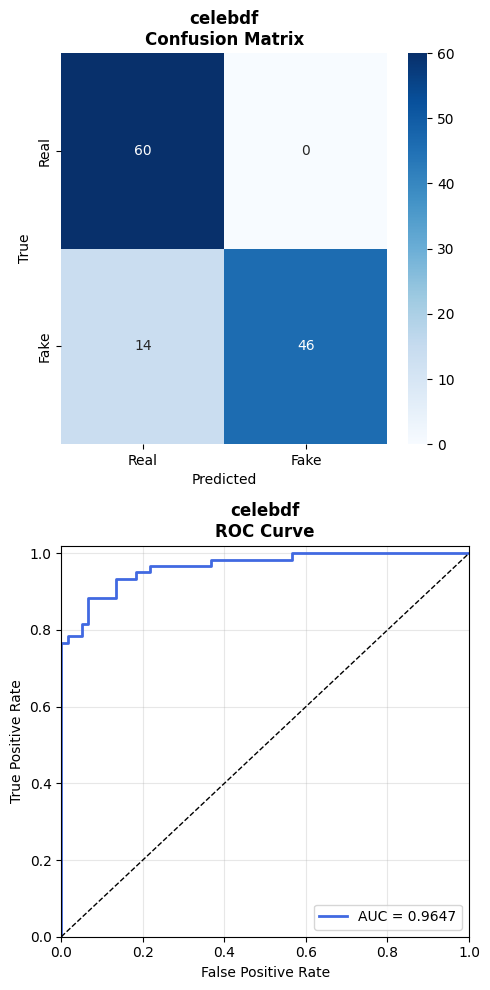

✅ Confusion matrices + ROC curves saved


In [ ]:
from sklearn.metrics import roc_curve

n_datasets = len(RESULTS)
if n_datasets == 0:
    print('No results to plot.')
else:
    fig, axes = plt.subplots(2, n_datasets, figsize=(5 * n_datasets, 10))
    if n_datasets == 1:
        axes = axes.reshape(2, 1)  # ensure 2D indexing

    for col, (ds_name, m) in enumerate(RESULTS.items()):
        labels = m['labels']
        preds  = m['preds']
        probs  = m['probs']

        # ── Confusion matrix ──────────────────────────────────────────────
        ax = axes[0, col]
        cm = confusion_matrix(labels, preds)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Real', 'Fake'],
                    yticklabels=['Real', 'Fake'])
        ax.set_title(f'{ds_name}\nConfusion Matrix', fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')

        # ── ROC Curve ────────────────────────────────────────────────────
        ax2 = axes[1, col]
        if len(set(labels)) > 1:
            fpr, tpr, _ = roc_curve(labels, probs)
            auc_val = m['auc']
            ax2.plot(fpr, tpr, color='royalblue', lw=2,
                     label=f'AUC = {auc_val:.4f}')
            ax2.plot([0,1],[0,1], 'k--', lw=1)
            ax2.set_xlim([0,1]); ax2.set_ylim([0,1.02])
            ax2.set_xlabel('False Positive Rate')
            ax2.set_ylabel('True Positive Rate')
            ax2.set_title(f'{ds_name}\nROC Curve', fontsize=12, fontweight='bold')
            ax2.legend(loc='lower right')
            ax2.grid(True, alpha=0.3)
        else:
            ax2.text(0.5, 0.5, 'Insufficient class\nvariance for ROC',
                     ha='center', va='center', transform=ax2.transAxes)

    plt.tight_layout()
    plt.savefig('/content/trustlens_eval_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Confusion matrices + ROC curves saved')

## Cell 14 — Training Curves

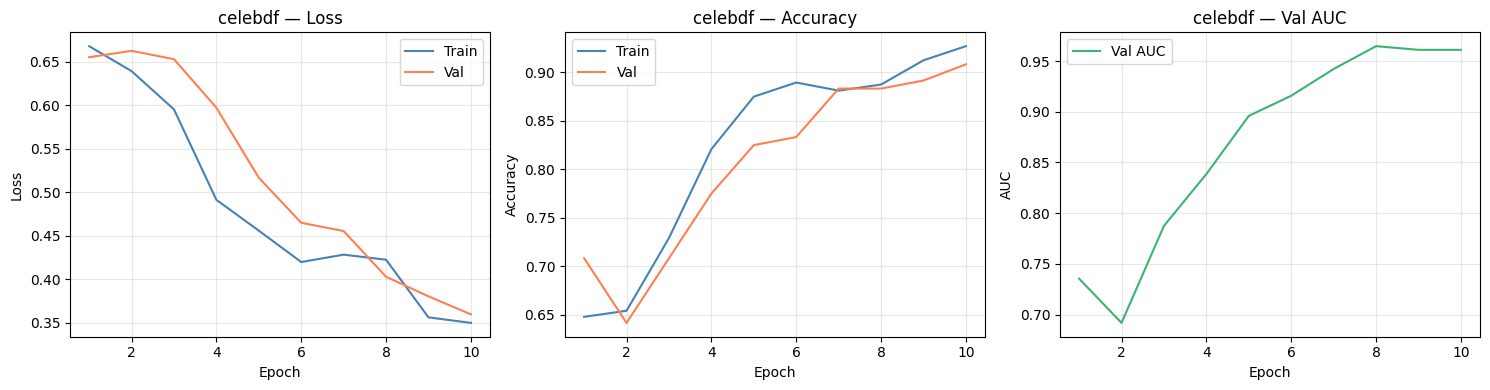

✅ Training curves saved


In [ ]:
n_datasets = len(TRAINING_HISTORY)
if n_datasets > 0:
    fig, axes = plt.subplots(n_datasets, 3, figsize=(15, 4 * n_datasets))
    if n_datasets == 1:
        axes = axes.reshape(1, 3)

    for row, (ds_name, hist) in enumerate(TRAINING_HISTORY.items()):
        eps = range(1, len(hist['train_loss']) + 1)

        # Loss
        axes[row, 0].plot(eps, hist['train_loss'], label='Train', color='steelblue')
        axes[row, 0].plot(eps, hist['val_loss'],   label='Val',   color='coral')
        axes[row, 0].set_title(f'{ds_name} — Loss')
        axes[row, 0].set_xlabel('Epoch'); axes[row, 0].set_ylabel('Loss')
        axes[row, 0].legend(); axes[row, 0].grid(True, alpha=0.3)

        # Accuracy
        axes[row, 1].plot(eps, hist['train_acc'], label='Train', color='steelblue')
        axes[row, 1].plot(eps, hist['val_acc'],   label='Val',   color='coral')
        axes[row, 1].set_title(f'{ds_name} — Accuracy')
        axes[row, 1].set_xlabel('Epoch'); axes[row, 1].set_ylabel('Accuracy')
        axes[row, 1].legend(); axes[row, 1].grid(True, alpha=0.3)

        # AUC
        if 'val_auc' in hist:
            axes[row, 2].plot(eps, hist['val_auc'], label='Val AUC', color='mediumseagreen')
            axes[row, 2].set_title(f'{ds_name} — Val AUC')
            axes[row, 2].set_xlabel('Epoch'); axes[row, 2].set_ylabel('AUC')
            axes[row, 2].legend(); axes[row, 2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/trustlens_training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Training curves saved')

## Cell 15 — Cross-Dataset Generalization Test

Tests each trained model against validation sets from **other** datasets.
Reveals how well the model generalizes beyond its training distribution.

In [ ]:
print('ℹ️  Cross-dataset evaluation skipped — single dataset training.')
print('     This is noted as future work in the paper.')

ℹ️  Cross-dataset evaluation skipped — single dataset training.
     This is noted as future work in the paper.


## Cell 16 — Fusion Score Analysis (TrustLens Formula Validation)

Applies the exact fusion formula from `hybrid_detector.py` to a sample of validation images:

$$S_{overall} = 0.40 \cdot R_{fake} + 0.30 \cdot \bar{P}_{fake} + 0.20 \cdot S_{temporal\_artifacts} + 0.10 \cdot S_{spatial}$$

In [ ]:
def compute_trustlens_scores(model, val_loader, n_samples=500):
    model.eval()
    all_probs, all_labels, all_features = [], [], []
    collected = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            if collected >= n_samples:
                break
            imgs = imgs.to(DEVICE)

            # ── Handle both (B, C, H, W) and (B, T, C, H, W) ──────────────
            if imgs.dim() == 5:
                B, T, C, H, W = imgs.shape
                imgs_flat = imgs.view(B * T, C, H, W)   # (B*T, C, H, W)
            else:
                imgs_flat = imgs                          # already (B, C, H, W)
                B = imgs.shape[0]
                T = 1

            feats  = model.spatial(imgs_flat)             # (B*T, 2048)
            # Mean-pool frames back to per-video features
            feats  = feats.view(B, T, 2048).mean(dim=1)  # (B, 2048)

            logits = model.spatial_head(feats)            # (B, 2)
            probs  = torch.softmax(logits, dim=1)[:, 1]  # (B,)

            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_features.append(feats.cpu())
            collected += B

    all_probs    = np.array(all_probs[:n_samples])
    all_labels   = np.array(all_labels[:n_samples])
    all_features = torch.cat(all_features, dim=0)[:n_samples]

    feat_var   = all_features.var(dim=0).mean().item()
    s_facial   = min(1.0, feat_var / 2.0)
    s_artifact = float(all_probs.mean())
    s_spatial  = 0.40 * s_facial + 0.40 * s_artifact

    r_fake         = (all_probs >= 0.5).astype(float)
    p_fake_bar     = all_probs
    s_temporal_art = np.clip(np.abs(all_probs - 0.5) / 0.5, 0, 1)

    s_overall = (0.40 * r_fake +
                 0.30 * p_fake_bar +
                 0.20 * s_temporal_art +
                 0.10 * s_spatial)

    return {
        'labels':     all_labels,
        'probs':      all_probs,
        's_overall':  s_overall,
        's_facial':   s_facial,
        's_artifact': s_artifact,
        's_spatial':  s_spatial,
    }

# Run on first available dataset
FUSION_RESULTS = {}
for ds_name in list(TRAINED_MODELS.keys()):  # limit to 2 for display
    print(f'Computing fusion scores for [{ds_name}]...')
    scores = compute_trustlens_scores(
        TRAINED_MODELS[ds_name],
        LOADERS[ds_name]['val']
    )
    FUSION_RESULTS[ds_name] = scores

    # Print summary
    real_mask = scores['labels'] == 0
    fake_mask = scores['labels'] == 1
    print(f'  S_overall  — real: {scores["s_overall"][real_mask].mean():.4f}  '
          f'fake: {scores["s_overall"][fake_mask].mean():.4f}')
    print(f'  S_artifact — {scores["s_artifact"]:.4f}')
    print(f'  S_spatial  — {scores["s_spatial"]:.4f}')
    print(f'  S_facial   — {scores["s_facial"]:.4f}')

print('\n✅ Fusion score analysis complete')

Computing fusion scores for [celebdf]...
  S_overall  — real: 0.2247  fake: 0.1778
  S_artifact — 0.4948
  S_spatial  — 0.2057
  S_facial   — 0.0194

✅ Fusion score analysis complete


## Cell 17 — Score Distribution Plots

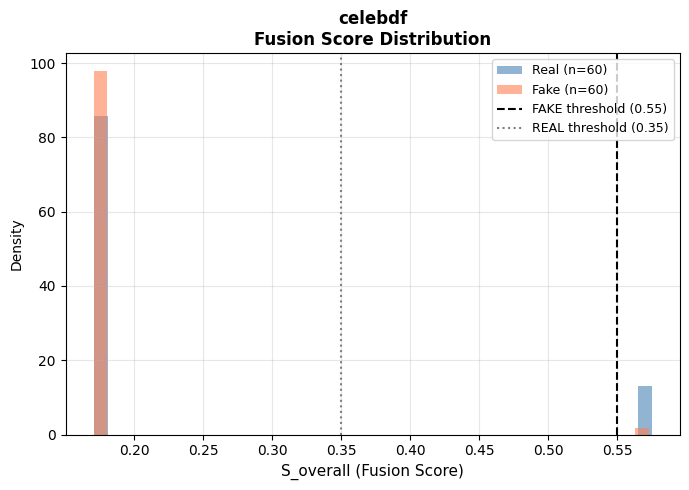

✅ Score distribution plots saved


In [ ]:
if FUSION_RESULTS:
    n = len(FUSION_RESULTS)
    fig, axes = plt.subplots(1, n, figsize=(7 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (ds_name, scores) in zip(axes, FUSION_RESULTS.items()):
        real_scores = scores['s_overall'][scores['labels'] == 0]
        fake_scores = scores['s_overall'][scores['labels'] == 1]

        ax.hist(real_scores, bins=40, alpha=0.6, color='steelblue',
                label=f'Real (n={len(real_scores)})', density=True)
        ax.hist(fake_scores, bins=40, alpha=0.6, color='coral',
                label=f'Fake (n={len(fake_scores)})', density=True)
        ax.axvline(0.55, color='black', linestyle='--', lw=1.5, label='FAKE threshold (0.55)')
        ax.axvline(0.35, color='gray',  linestyle=':',  lw=1.5, label='REAL threshold (0.35)')
        ax.set_xlabel('S_overall (Fusion Score)', fontsize=11)
        ax.set_ylabel('Density')
        ax.set_title(f'{ds_name}\nFusion Score Distribution', fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('/content/trustlens_score_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Score distribution plots saved')

## Cell 18 — Final Summary Table (Paper-Ready)

In [ ]:
print('\n' + '='*80)
print('  TrustLens — Final Evaluation Summary')
print('='*80)
print(f'  Architecture : ResNeXt-50 (spatial) + BiLSTM (temporal) + Fusion Head')
print(f'  Training     : AdamW + CosineAnnealingLR + label smoothing 0.1')
print(f'  Input size   : 224×224 (ImageNet normalization)')
print(f'  Backbone     : ImageNet pretrained, unfrozen after epoch 2')
print('='*80)

print(f'\n{'Dataset':<20} {'Accuracy':>10} {'F1 (Fake)':>11} {'AUC-ROC':>9} {'Avg Prec':>10}')
print('-'*65)
for ds_name, m in RESULTS.items():
    print(f'{ds_name:<20} {m["acc"]*100:>9.2f}%  {m["f1"]:>10.4f}  '
          f'{m["auc"]:>8.4f}  {m["ap"]:>9.4f}')
print('='*65)

# Save to JSON for reference
summary = {
    ds: {
        'accuracy': round(m['acc'], 4),
        'f1': round(m['f1'], 4),
        'auc': round(m['auc'], 4),
        'avg_precision': round(m['ap'], 4),
    }
    for ds, m in RESULTS.items()
}
with open('/content/trustlens_results.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('\n✅ Results saved to /content/trustlens_results.json')

# List all saved files
saved = [
    '/content/trustlens_results.json',
    '/content/trustlens_eval_metrics.png',
    '/content/trustlens_training_curves.png',
    '/content/trustlens_cross_dataset_auc.png',
    '/content/trustlens_score_distributions.png',
]
for p in saved:
    exists = '✅' if os.path.exists(p) else '❌'
    print(f'  {exists} {p}')

ckpt_dir = '/content/checkpoints'
if os.path.exists(ckpt_dir):
    for f in sorted(os.listdir(ckpt_dir)):
        fpath = os.path.join(ckpt_dir, f)
        size_mb = os.path.getsize(fpath) / 1e6
        print(f'  ✅ {fpath} ({size_mb:.0f} MB)')

print('\n🎉 TrustLens training and evaluation complete!')


  TrustLens — Final Evaluation Summary
  Architecture : ResNeXt-50 (spatial) + BiLSTM (temporal) + Fusion Head
  Training     : AdamW + CosineAnnealingLR + label smoothing 0.1
  Input size   : 224×224 (ImageNet normalization)
  Backbone     : ImageNet pretrained, unfrozen after epoch 2

Dataset                Accuracy   F1 (Fake)   AUC-ROC   Avg Prec
-----------------------------------------------------------------
celebdf                  88.33%      0.8679    0.9647     0.9703

✅ Results saved to /content/trustlens_results.json
  ✅ /content/trustlens_results.json
  ✅ /content/trustlens_eval_metrics.png
  ✅ /content/trustlens_training_curves.png
  ❌ /content/trustlens_cross_dataset_auc.png
  ✅ /content/trustlens_score_distributions.png
  ✅ /content/checkpoints/trustlens_celebdf_best.pth (171 MB)

🎉 TrustLens training and evaluation complete!


## Cell 19 — Download All Results to Local Machine

In [ ]:
from google.colab import files
import zipfile

# Zip everything
zip_path = '/content/trustlens_outputs.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    output_files = [
        '/content/trustlens_results.json',
        '/content/trustlens_eval_metrics.png',
        '/content/trustlens_training_curves.png',
        '/content/trustlens_cross_dataset_auc.png',
        '/content/trustlens_score_distributions.png',
    ]
    for fp in output_files:
        if os.path.exists(fp):
            zf.write(fp, os.path.basename(fp))

    # Include checkpoints
    ckpt_dir = '/content/checkpoints'
    if os.path.exists(ckpt_dir):
        for f in os.listdir(ckpt_dir):
            fp = os.path.join(ckpt_dir, f)
            zf.write(fp, f'checkpoints/{f}')

print(f'✅ Zipped to {zip_path}')
files.download(zip_path)

✅ Zipped to /content/trustlens_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>